In [2]:
import os

print(os.getcwd())

e:\Internship\mutual_fund_analysis\notebooks\notebooks


In [3]:
import os

print(os.listdir())

['Advanced_Analytics.ipynb']


In [5]:
import pandas as pd

nav_history = pd.read_csv(
    "../../data/processed/nav_history_cleaned.csv"
)

print(nav_history.shape)

(46000, 3)


In [6]:
print(nav_history.columns.tolist())
nav_history.head()

['amfi_code', 'date', 'nav']


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
var_cvar = []

for fund in nav_history["amfi_code"].unique():

    returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_cvar.append([
        fund,
        var_95,
        cvar_95
    ])

var_cvar_report = pd.DataFrame(
    var_cvar,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [10]:
var_cvar_report.sort_values(
    "VaR_95"
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [11]:
var_cvar_report.to_csv(
    "../../reports/var_cvar_report.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [12]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

rolling_sharpe = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_sharpe.append(temp)

rolling_sharpe_df = pd.concat(
    rolling_sharpe
)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [13]:
rolling_sharpe_df.groupby(
    "amfi_code"
)["rolling_sharpe"].mean().sort_values(
    ascending=False
).head()

amfi_code
120507    13.558546
120844    12.478178
101208    11.995642
120843     1.997692
148567     1.890422
Name: rolling_sharpe, dtype: float64

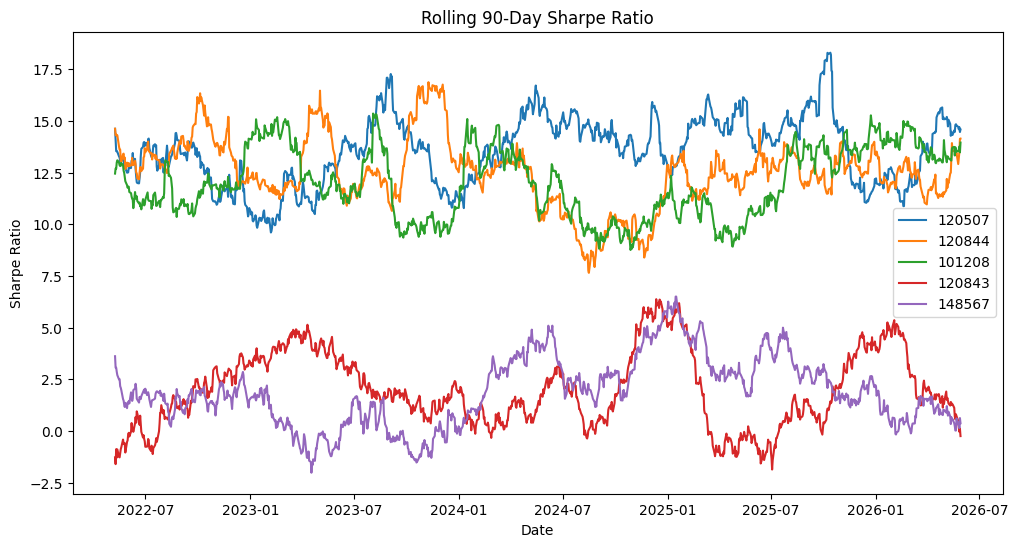

In [14]:
top5 = (
    rolling_sharpe_df.groupby(
        "amfi_code"
    )["rolling_sharpe"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(12,6))

for fund in top5:

    temp = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.show()

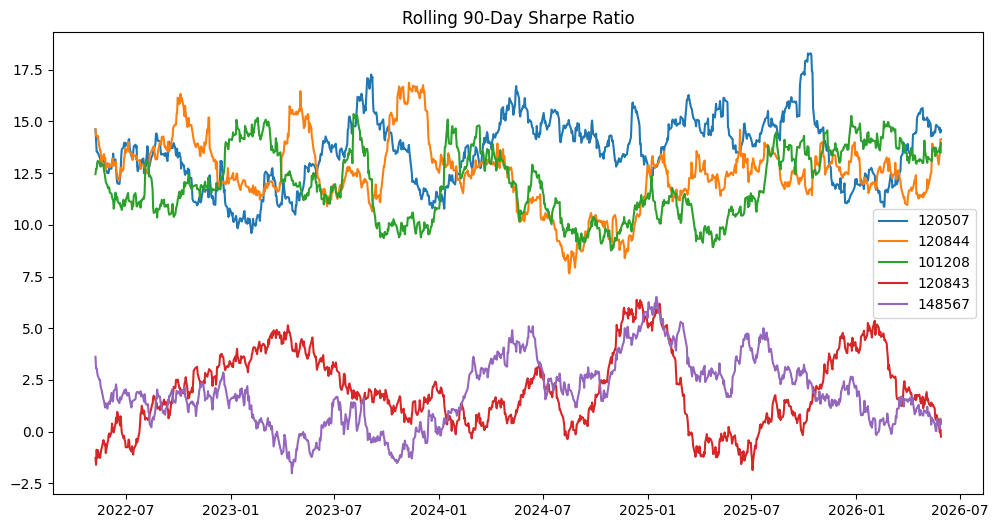

In [15]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")

plt.savefig(
    "../../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
investor_transactions = pd.read_csv(
    "../../data/processed/investor_transactions_cleaned.csv"
)

print(investor_transactions.shape)

(32778, 13)


In [18]:
print(investor_transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [19]:
print("\n".join(investor_transactions.columns))

investor_id
transaction_date
amfi_code
transaction_type
amount_inr
state
city
city_tier
age_group
gender
annual_income_lakh
payment_mode
kyc_status


In [20]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

cohort = investor_transactions.groupby(
    "investor_id"
)["transaction_date"].min().reset_index()

cohort["cohort_year"] = cohort["transaction_date"].dt.year

cohort.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [21]:
cohort_summary = cohort.groupby(
    "cohort_year"
).agg(
    total_investors=("investor_id", "count")
).reset_index()

cohort_summary

,cohort_year,total_investors
0,2024,4803
1,2025,197


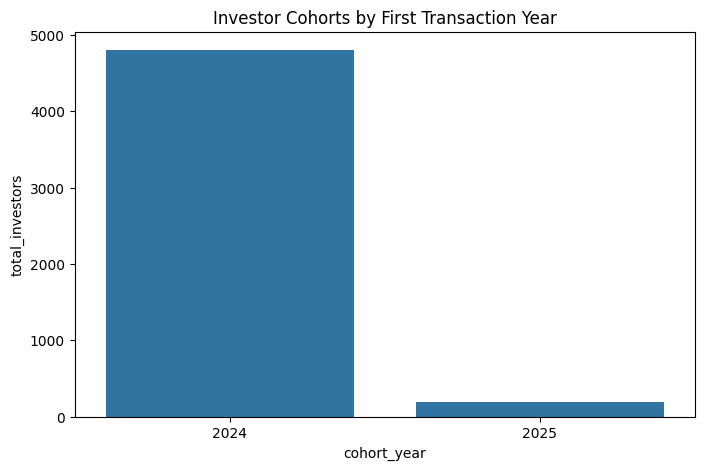

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cohort_summary,
    x="cohort_year",
    y="total_investors"
)

plt.title("Investor Cohorts by First Transaction Year")
plt.show()

In [23]:
sip_txn = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days


In [24]:
sip_continuity = sip_txn.groupby(
    "investor_id"
)["gap_days"].mean().reset_index()

sip_continuity.columns = [
    "investor_id",
    "avg_gap_days"
]

sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_continuity.head()

,investor_id,avg_gap_days,status


In [25]:
sip_continuity["status"].value_counts()

Series([], Name: count, dtype: int64)

In [27]:
scheme_performance = pd.read_csv(
    "../../data/processed/scheme_performance_cleaned.csv"
)

print(scheme_performance.shape)

(40, 19)


In [28]:
print(scheme_performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [29]:
print(investor_transactions["transaction_type"].value_counts())

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


In [30]:
sip_txn = investor_transactions[
    investor_transactions["transaction_type"].str.upper() == "SIP"
]

print(sip_txn.shape)

(19716, 13)


In [31]:
for col in scheme_performance.columns:
    print(col)

amfi_code
scheme_name
fund_house
category
plan
return_1yr_pct
return_3yr_pct
return_5yr_pct
benchmark_3yr_pct
alpha
beta
sharpe_ratio
sortino_ratio
std_dev_ann_pct
max_drawdown_pct
aum_crore
expense_ratio_pct
morningstar_rating
risk_grade


In [32]:
cohort_summary

,cohort_year,total_investors
0,2024,4803
1,2025,197


In [33]:
print(scheme_performance["risk_grade"].value_counts())

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [34]:
def recommend_funds(risk_grade):

    recommendations = (
        scheme_performance[
            scheme_performance["risk_grade"] == risk_grade
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            "scheme_name",
            "fund_house",
            "sharpe_ratio",
            "return_3yr_pct",
            "risk_grade"
        ]
    ]

In [35]:
recommend_funds("High")

,scheme_name,fund_house,sharpe_ratio,return_3yr_pct,risk_grade
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,0.96,18.23,High
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.95,18.08,High
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,0.90,17.16,High


In [37]:
portfolio_holdings = pd.read_csv(
    "../../data/raw/09_portfolio_holdings.csv"
)

print(portfolio_holdings.shape)

(322, 8)


In [38]:
for col in portfolio_holdings.columns:
    print(col)

amfi_code
stock_symbol
stock_name
sector
weight_pct
market_value_cr
current_price_inr
portfolio_date


In [39]:
sector_weights = (
    portfolio_holdings
    .groupby("sector")["weight_pct"]
    .sum()
)

sector_weights

sector
Automobile        323.65
Banking           652.26
Cement            105.03
Consumer Goods    127.61
Diversified       169.23
Energy            117.91
FMCG              229.11
IT                455.47
Infrastructure    192.16
NBFC              119.09
Paints             89.86
Pharma            407.45
Telecom           145.62
Utilities         265.54
Name: weight_pct, dtype: float64

In [40]:
hhi = (
    (sector_weights / sector_weights.sum()) ** 2
).sum()

print("HHI Score:", round(hhi, 4))

HHI Score: 0.1018


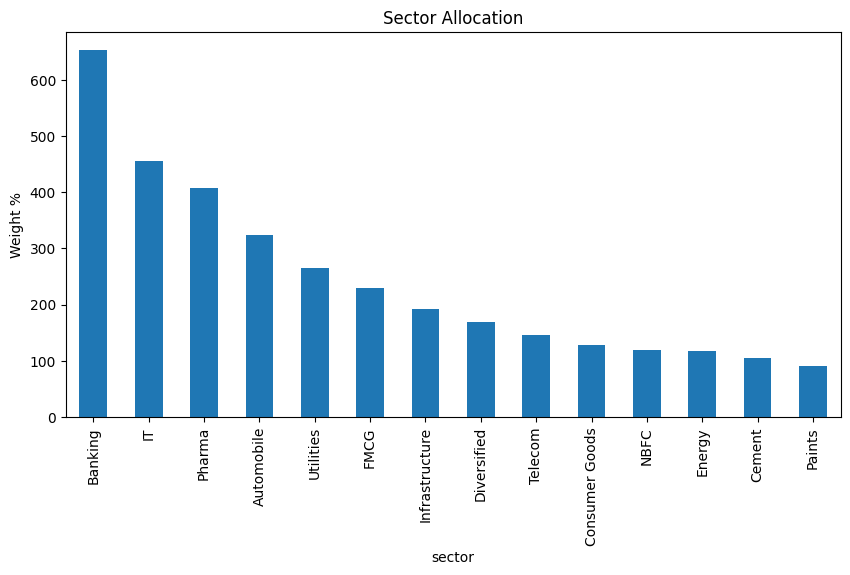

In [41]:
plt.figure(figsize=(10,5))

sector_weights.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Sector Allocation")
plt.ylabel("Weight %")
plt.show()

In [42]:
sip_continuity.to_csv(
    "../../reports/sip_continuity.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [43]:
recommend_funds("High")

,scheme_name,fund_house,sharpe_ratio,return_3yr_pct,risk_grade
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,0.96,18.23,High
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.95,18.08,High
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,0.90,17.16,High


In [44]:
recommend_funds("High").to_csv(
    "../../reports/recommended_funds.csv",
    index=False
)

In [45]:
print(portfolio_holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [46]:
sector_weights = (
    portfolio_holdings
    .groupby("sector")["weight_pct"]
    .sum()
)

hhi = (
    (sector_weights / sector_weights.sum())**2
).sum()

print("HHI:", hhi)

HHI: 0.10180931937054813


In [47]:
sip_continuity.to_csv(
    "../../reports/sip_continuity.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


 Advanced Analytics Insights

1. Cohort 2024 contributed the majority of investors compared to 2025.

2. SIP transactions account for the highest share of investor activity.

3. Funds with higher Sharpe ratios delivered better risk-adjusted returns.

4. VaR and CVaR analysis identified funds with the highest downside risk.

5. Rolling Sharpe trends indicate changing risk-adjusted performance across time.